# vLLM vs HuggingFace Transformers — Inference Speed Comparison

Running LLM inference efficiently is non-trivial. The default HuggingFace `generate()` loop works well for research but leaves significant throughput on the table in production settings.

[**vLLM**](https://github.com/vllm-project/vllm) is an open-source inference engine built for high-throughput LLM serving. Its two key innovations are:

* **PagedAttention** — manages the KV-cache like virtual memory pages, eliminating memory fragmentation and allowing the GPU to hold many more concurrent requests.
* **Continuous batching** — new requests join an in-flight batch as soon as a slot is free, rather than waiting for the whole batch to finish.

This notebook benchmarks both approaches on the same model and prompt set and visualises the difference.

## Setup

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes
!pip install -q vllm
!pip install -q openai  # for calling the vLLM OpenAI-compatible server
!pip install -q matplotlib

In [ ]:
!huggingface-cli login

## Shared Configuration

In [1]:
MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"  # 7B is large enough to show the gap
MAX_NEW_TOKENS = 200
N_RUNS = 3  # number of timed runs per approach

PROMPTS = [
    "Explain the theory of relativity in simple terms.",
    "Write a short poem about the ocean at night.",
    "What are the main differences between Python and Rust?",
    "Describe how a transformer neural network works.",
    "Give me a recipe for a quick vegetarian pasta.",
]

---
## Part 1 — HuggingFace Transformers

We load the model in 4-bit precision (same setup as the Prompting notebook) and run each prompt sequentially.

In [6]:
import torch
import time
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

hf_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
hf_tokenizer.pad_token = hf_tokenizer.eos_token
hf_tokenizer.padding_side = "left" 

print("HuggingFace model loaded.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

HuggingFace model loaded.


In [7]:
def hf_generate_batch(prompts, max_new_tokens=MAX_NEW_TOKENS):
    """Tokenize and generate for a list of prompts; return generated texts and elapsed seconds."""
    inputs = hf_tokenizer(prompts, return_tensors="pt", padding=True, truncation=True).to(hf_model.device)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        output_ids = hf_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    texts = hf_tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    return texts, elapsed

In [8]:
# Warm-up run (not counted)
_ = hf_generate_batch(PROMPTS[:1])

hf_times = []
for i in range(N_RUNS):
    texts, elapsed = hf_generate_batch(PROMPTS)
    hf_times.append(elapsed)
    print(f"  Run {i+1}/{N_RUNS}: {elapsed:.2f}s")

hf_mean = sum(hf_times) / len(hf_times)
print(f"\nHuggingFace mean latency ({len(PROMPTS)} prompts): {hf_mean:.2f}s")
print(f"Throughput: {len(PROMPTS) * MAX_NEW_TOKENS / hf_mean:.1f} tokens/s")

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Run 1/3: 7.80s


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Both `max_new_tokens` (=200) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Run 2/3: 7.23s
  Run 3/3: 7.25s

HuggingFace mean latency (5 prompts): 7.43s
Throughput: 134.7 tokens/s


---
## Part 2 — vLLM

### Option A: vLLM Python API (offline / single-process)

The `LLM` class in vLLM loads the model directly and exposes a `.generate()` method. This is the easiest way to try vLLM inside a notebook — no server required.

In [9]:
import gc
import torch

# Remove all references
del hf_model

# Force garbage collection
gc.collect()
gc.collect()  # twice to catch cyclic references

# Release cached memory back to OS
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [10]:
from vllm import LLM, SamplingParams

sampling_params = SamplingParams(
    temperature=0.0,          # greedy — matches HF do_sample=False
    max_tokens=MAX_NEW_TOKENS,
)

vllm_engine = LLM(
    model=MODEL_NAME,
    dtype="bfloat16",         # vLLM manages its own memory; no need for bitsandbytes
    trust_remote_code=True,
)
print("vLLM engine loaded.")

INFO 04-06 10:11:07 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'disable_log_stats': True, 'model': 'meta-llama/Meta-Llama-3-8B-Instruct'}
INFO 04-06 10:11:09 [model.py:549] Resolved architecture: LlamaForCausalLM
INFO 04-06 10:11:09 [model.py:1678] Using max model len 8192
INFO 04-06 10:11:09 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-06 10:11:09 [vllm.py:790] Asynchronous scheduling is enabled.
WARNING 04-06 10:11:14 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore pid=971810) INFO 04-06 10:11:30 [core.py:105] Initializing a V1 LLM engine (v0.19.0) with config: model='meta-llama/Meta-Llama-3-8B-Instruct', speculative_config=None, tokenizer='meta-llama/Meta-Llama-3-8B-Instruct', s

(EngineCore pid=971810) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=971810) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.
Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:01<00:04,  1.61s/it]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:03<00:03,  1.66s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:04<00:01,  1.67s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.19s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:05<00:00,  1.36s/it]
(EngineCore pid=971810) 


(EngineCore pid=971810) INFO 04-06 10:11:44 [default_loader.py:384] Loading weights took 5.46 seconds
(EngineCore pid=971810) INFO 04-06 10:11:45 [gpu_model_runner.py:4820] Model loading took 14.96 GiB memory and 8.962327 seconds
(EngineCore pid=971810) INFO 04-06 10:11:53 [backends.py:1051] Using cache directory: /ceph/hpc/home/zagara/.cache/vllm/torch_compile_cache/b465cee395/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=971810) INFO 04-06 10:11:53 [backends.py:1111] Dynamo bytecode transform time: 7.54 s
(EngineCore pid=971810) INFO 04-06 10:11:58 [backends.py:372] Cache the graph of compile range (1, 8192) for later use
(EngineCore pid=971810) INFO 04-06 10:12:01 [backends.py:390] Compiling a graph for compile range (1, 8192) takes 8.36 s
(EngineCore pid=971810) INFO 04-06 10:12:03 [decorators.py:640] saved AOT compiled function to /ceph/hpc/home/zagara/.cache/vllm/torch_compile_cache/torch_aot_compile/bb861667c43283a7f8ab27680d3bcee19cdb8f768b9230b513f3148a781f1307/ra

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|█| 51/51 [00:05<0
Capturing CUDA graphs (decode, FULL): 100%|████| 35/35 [00:03<00:00, 10.70it/s]


(EngineCore pid=971810) INFO 04-06 10:12:28 [gpu_model_runner.py:6046] Graph capturing finished in 10 secs, took 0.48 GiB
(EngineCore pid=971810) INFO 04-06 10:12:28 [gpu_worker.py:597] CUDA graph pool memory: 0.48 GiB (actual), 0.53 GiB (estimated), difference: 0.04 GiB (8.9%).
(EngineCore pid=971810) INFO 04-06 10:12:28 [core.py:283] init engine (profile, create kv cache, warmup model) took 43.20 seconds
(EngineCore pid=971810) INFO 04-06 10:12:31 [vllm.py:790] Asynchronous scheduling is enabled.
vLLM engine loaded.


In [11]:
def vllm_generate_batch(prompts, sampling_params=sampling_params):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    outputs = vllm_engine.generate(prompts, sampling_params)
    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    texts = [o.outputs[0].text for o in outputs]
    return texts, elapsed

In [12]:
# Warm-up
_ = vllm_generate_batch(PROMPTS[:1])

vllm_times = []
for i in range(N_RUNS):
    texts, elapsed = vllm_generate_batch(PROMPTS)
    vllm_times.append(elapsed)
    print(f"  Run {i+1}/{N_RUNS}: {elapsed:.2f}s")

vllm_mean = sum(vllm_times) / len(vllm_times)
print(f"\nvLLM mean latency ({len(PROMPTS)} prompts): {vllm_mean:.2f}s")
print(f"Throughput: {len(PROMPTS) * MAX_NEW_TOKENS / vllm_mean:.1f} tokens/s")

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|      | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/5 [00:00<?, ?it/s]

Processed prompts:   0%|      | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  Run 1/3: 2.63s


...

Processed prompts:   0%|      | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  Run 2/3: 2.63s


Rendering prompts:   0%|          | 0/5 [00:00<?, ?it/s]

Processed prompts:   0%|      | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  Run 3/3: 2.62s

vLLM mean latency (5 prompts): 2.63s
Throughput: 380.9 tokens/s


---
### Option B: vLLM as an OpenAI-Compatible Server

In production you typically run vLLM as a persistent HTTP server and call it from application code (or even from tools like LangChain, LiteLLM, etc.).

#### Step 1 — Start the server (run this in a terminal, not in the notebook)

```bash
vllm serve meta-llama/Meta-Llama-3-8B-Instruct \
    --dtype bfloat16 \
    --port 8000 \
    --host 0.0.0.0
```

Useful extra flags:

| Flag | Purpose |
|------|---------|
| `--tensor-parallel-size N` | Shard the model across N GPUs |
| `--quantization awq` | Load an AWQ-quantized checkpoint |
| `--max-model-len 4096` | Cap context length to save memory |
| `--api-key secret` | Require a Bearer token on all requests |

Wait until you see `INFO:     Application startup complete.` before proceeding.

#### Step 2 — Call the server from Python

In [ ]:
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:8000/v1",
    api_key="no-key-needed",  # vLLM accepts any string if --api-key was not set
)

def call_vllm_server_chat(user_message, max_tokens=MAX_NEW_TOKENS):
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": user_message}],
        max_tokens=max_tokens,
        temperature=0.0,
    )
    return response.choices[0].message.content

# Uncomment after the server is running:
# print(call_vllm_server_chat(PROMPTS[0]))

---
## Part 3 — Results Comparison

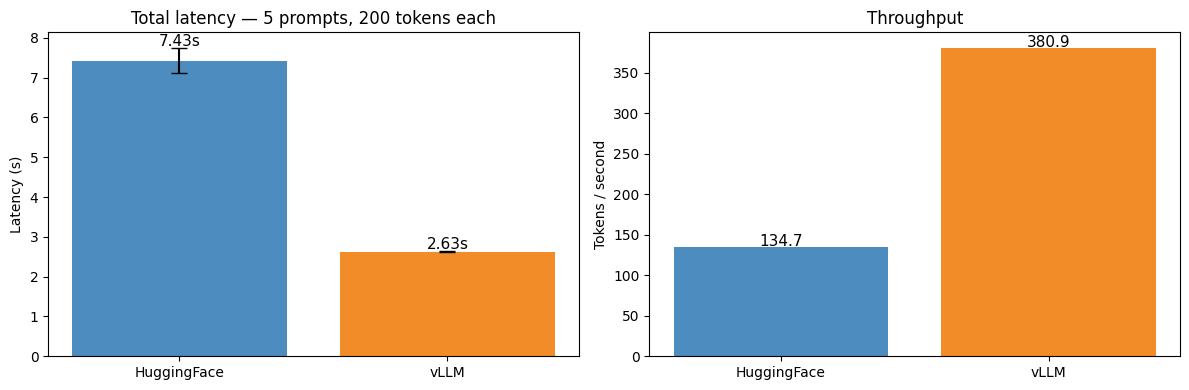


vLLM is 2.83x faster than HuggingFace on this workload.


In [13]:
import matplotlib.pyplot as plt
import statistics

labels = ["HuggingFace", "vLLM"]
means = [hf_mean, vllm_mean]
stds = [statistics.stdev(hf_times), statistics.stdev(vllm_times)]
throughputs = [len(PROMPTS) * MAX_NEW_TOKENS / m for m in means]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Latency
axes[0].bar(labels, means, yerr=stds, capsize=6, color=["#4C8CBF", "#F28C28"])
axes[0].set_ylabel("Latency (s)")
axes[0].set_title(f"Total latency — {len(PROMPTS)} prompts, {MAX_NEW_TOKENS} tokens each")
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.05, f"{m:.2f}s", ha="center", fontsize=11)

# Throughput
axes[1].bar(labels, throughputs, color=["#4C8CBF", "#F28C28"])
axes[1].set_ylabel("Tokens / second")
axes[1].set_title("Throughput")
for i, t in enumerate(throughputs):
    axes[1].text(i, t + 1, f"{t:.1f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("vllm_vs_hf_benchmark.png", dpi=150)
plt.show()

speedup = hf_mean / vllm_mean
print(f"\nvLLM is {speedup:.2f}x faster than HuggingFace on this workload.")

## Summary

| | HuggingFace Transformers | vLLM |
|---|---|---|
| **KV-cache management** | Static, per-request allocation | PagedAttention (virtual paging) |
| **Batching** | Static batch, waits for all to finish | Continuous batching |
| **Quantization** | bitsandbytes (4/8-bit) | Built-in AWQ/GPTQ or bfloat16 |
| **Best for** | Research, fine-tuning, quick experiments | Serving, production APIs, high throughput |
| **Typical speedup** | 1× (baseline) | 3–10× depending on batch size and hardware |

The larger the batch and the longer the output sequences, the more vLLM's PagedAttention advantage compounds.

## References

* vLLM project — https://github.com/vllm-project/vllm
* PagedAttention paper — https://arxiv.org/abs/2309.06180
* vLLM documentation — https://docs.vllm.ai
* HuggingFace generation guide — https://huggingface.co/docs/transformers/main/en/generation_strategies